In [1]:
import pandas as pd
import numpy as np
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

# 1) Load your final CSV
df = pd.read_csv("delhi_air_anomaly_ready.csv", parse_dates=["date"])  # uses your date column
df = df.sort_values("date")
df = df.set_index("date")
df.index.name = "date"

print(df.columns)


Index(['year', 'month', 'season', 'pm2.5', 'pm10', 'no2', 'so2', 'co', 'o3',
       'temperature_celsius', 'humidity', 'wind_kph', 'fire_count_all_india',
       'pm25_7day_avg', 'pm25_7day_std', 'pm25_deviation', 'aqi',
       'aqi_bucket'],
      dtype='object')


In [2]:
# 2) Pick feature columns for anomaly detection
feature_cols = [
    "pm2.5", "pm10", "no2", "so2", "co", "o3",
    "temperature_celsius", "humidity", "wind_kph",
    "fire_count_all_india",
    "pm25_deviation",   # uses your rolling deviation feature
]

X = df[feature_cols].copy()

# Clean missing values
X = X.interpolate(limit_direction="both")
X = X.fillna(0)

# Scale
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


In [3]:
# 3) Time split: train on older years, test on newer
split_date = "2020-01-01"   # change if you want

train_mask = df.index < split_date
test_mask  = df.index >= split_date

X_train = X_scaled[train_mask]
X_test  = X_scaled[test_mask]

df_train = df[train_mask].copy()
df_test  = df[test_mask].copy()


In [4]:
# 4) Train IsolationForest on train period only
iso = IsolationForest(
    n_estimators=200,
    contamination=0.03,   # adjust 0.01–0.05 later
    random_state=42,
)
iso.fit(X_train)

# Scores and labels on train
train_scores = iso.decision_function(X_train)   # higher = more normal
train_preds  = iso.predict(X_train)             # -1 = anomaly, 1 = normal

# Scores and labels on test (future)
test_scores = iso.decision_function(X_test)
test_preds  = iso.predict(X_test)

# Put back into dataframes (flip sign so higher = more anomalous)
df_train["iforest_score"] = -train_scores
df_train["iforest_label"] = (train_preds == -1)

df_test["iforest_score"] = -test_scores
df_test["iforest_label"] = (test_preds == -1)

# Combine back
df_iforest = pd.concat([df_train, df_test]).sort_index()


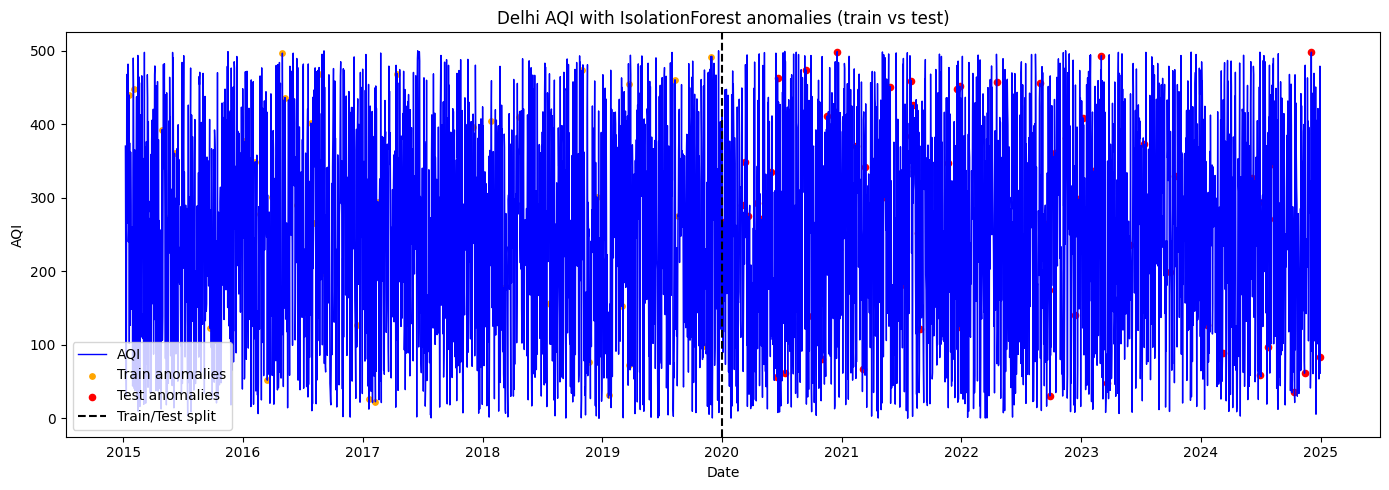

In [5]:
plt.figure(figsize=(14, 5))
plt.plot(df_iforest.index, df_iforest["aqi"], label="AQI", color="blue", linewidth=1)

anoms_train = df_train[df_train["iforest_label"]]
anoms_test  = df_test[df_test["iforest_label"]]

# Mark train anomalies in orange, test anomalies in red
plt.scatter(anoms_train.index, anoms_train["aqi"],
            color="orange", s=15, label="Train anomalies")
plt.scatter(anoms_test.index, anoms_test["aqi"],
            color="red", s=20, label="Test anomalies")

plt.axvline(pd.to_datetime(split_date), color="black", linestyle="--", label="Train/Test split")
plt.xlabel("Date")
plt.ylabel("AQI")
plt.title("Delhi AQI with IsolationForest anomalies (train vs test)")
plt.legend()
plt.tight_layout()
plt.show()


In [6]:
df_iforest.to_csv("delhi_air_anomaly_with_iforest_train_test.csv")
